# The Blockbuster Formula
## Causal Analysis of Box Office Success Using Bayesian Networks

**Author:** Steve Meta  
**Program:** Master's in Data Science â€” IE University  
**Date:** April 2026

---

### Research Question
> *Do high-profile casts and large production/marketing budgets causally drive box office success, or are other factors (genre, release timing, audience reception) stronger drivers?*

### Approach
Rather than treating this as a pure prediction problem, we use a **Bayesian Network** to model the *causal structure* of box office success. This allows us to:
- Understand *why* certain movies succeed, not just predict which ones will
- Run counterfactual queries ("what if we swapped the cast?")
- Quantify the relative influence of each factor

### Notebook Sections
1. Data Collection & Loading
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Bayesian Network (DAG + Fitting)
6. Probabilistic Inference & Counterfactual Reasoning
7. Baseline Model Comparison (Logistic Regression & Random Forest)
8. Sensitivity Analysis & Conclusion

---
## Section 1 â€” Data Collection & Loading

### What we're doing
We pull movie data from **The Movie Database (TMDb) API** â€” the most comprehensive freely available source for film metadata. For each movie released between 2000 and 2024, we collect:

- **Identity**: title, TMDb ID, release date
- **Financials**: production budget, worldwide revenue
- **Creative**: genres, top-billed cast (up to 5 actors)
- **Reception**: TMDb popularity score, vote average, vote count

### Why TMDb?
TMDb provides structured, machine-readable data via a well-documented REST API with a generous free tier. Budget/revenue data comes from the movie's `/details` endpoint, while cast data comes from the `/credits` endpoint. We page through `discover/movie` sorted by popularity to capture blockbuster-tier films.

### Data volume
We target **~3,000â€“5,000 movies** across 25 years. After filtering for budget > $10M in Section 2, we expect ~1,500â€“2,500 true blockbusters.

In [12]:
# â”€â”€ Imports â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import os
import time
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv
from tqdm.notebook import tqdm

# â”€â”€ Load API key from .env â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
load_dotenv()
TMDB_API_KEY = os.getenv('TMDB_API_KEY')

if not TMDB_API_KEY:
    raise ValueError("TMDb API key not found. Make sure .env contains TMDB_API_KEY=your_key")

#just making sure it's well loaded
#print(f"API key loaded: {TMDB_API_KEY[:6]}{'*' * (len(TMDB_API_KEY) - 6)}")

# â”€â”€ Directory setup â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Path('data').mkdir(exist_ok=True)
Path('outputs').mkdir(exist_ok=True)
print("Directories ready: data/ and outputs/")

Directories ready: data/ and outputs/


In [ ]:
# ── Smart loader: skip API calls if CSV already exists ───────────────────────
# On re-opening the notebook, run THIS cell first.
# If data/movies_raw.csv exists, it loads directly and skips all API calls.

RAW_PATH = Path("data/movies_raw.csv")

if RAW_PATH.exists():
    df_raw = pd.read_csv(RAW_PATH, parse_dates=["release_date"])
    print(f"Loaded existing data from {RAW_PATH}")
    print(f"Shape: {df_raw.shape}  |  Date range: {df_raw["release_date"].min().year} – {df_raw["release_date"].max().year}")
    print("Skipping API collection — jump straight to Section 2.")
else:
    print(f"{RAW_PATH} not found — run the API collection cells below to build it.")
    df_raw = None

In [13]:
# â”€â”€ TMDb API configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BASE_URL   = 'https://api.themoviedb.org/3'
HEADERS    = {'accept': 'application/json'}

# Years to collect (inclusive)
START_YEAR = 2000
END_YEAR   = 2024

# Pages per year â€” TMDb returns 20 movies/page, sorted by popularity desc.
# 10 pages Ã— 20 = 200 movies per year Ã— 25 years = up to 5,000 movies
PAGES_PER_YEAR = 10

# Politeness delay between API calls (seconds)
REQUEST_DELAY = 0.25

def tmdb_get(endpoint: str, params: dict = None) -> dict | None:
    """Make a GET request to the TMDb API. Returns JSON dict or None on error.
    Uses v3 API key authentication â€” passed as a query parameter, not Bearer token.
    """
    url = f"{BASE_URL}/{endpoint}"
    # v3 keys go in as ?api_key=xxx, not as Authorization: Bearer
    all_params = {'api_key': TMDB_API_KEY}
    if params:
        all_params.update(params)
    try:
        response = requests.get(url, headers=HEADERS, params=all_params, timeout=10)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Request failed for {endpoint}: {e}")
        return None

# â”€â”€ Quick connectivity test â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
test = tmdb_get('configuration')
if test:
    print("TMDb API connection successful!")
else:
    print("Connection failed â€” check your API key.")

TMDb API connection successful!


In [14]:
# â”€â”€ Step 1: Discover movie IDs by year â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# We use /discover/movie sorted by popularity descending, filtered by year.
# This gives us the most-discussed films for each year â€” exactly what we want
# for a blockbuster analysis.

def discover_movie_ids(year: int, pages: int = PAGES_PER_YEAR) -> list[int]:
    """Return a list of TMDb movie IDs for a given release year."""
    ids = []
    for page in range(1, pages + 1):
        data = tmdb_get('discover/movie', params={
            'primary_release_year': year,
            'sort_by': 'popularity.desc',
            'include_adult': False,
            'include_video': False,
            'page': page,
            'language': 'en-US',
            'with_original_language': 'en'  # English-language films only
        })
        if data and 'results' in data:
            ids.extend([m['id'] for m in data['results']])
        time.sleep(REQUEST_DELAY)
    return ids

# Collect IDs across all years
print(f"Discovering movie IDs from {START_YEAR} to {END_YEAR}...")
all_ids = []

for year in tqdm(range(START_YEAR, END_YEAR + 1), desc="Years"):
    year_ids = discover_movie_ids(year)
    all_ids.extend(year_ids)

# Remove duplicates (some films appear across year boundaries)
all_ids = list(set(all_ids))
print(f"\nTotal unique movie IDs collected: {len(all_ids)}")

Discovering movie IDs from 2000 to 2024...


Years:   0%|          | 0/25 [00:00<?, ?it/s]


Total unique movie IDs collected: 4996


In [15]:
# â”€â”€ Step 2: Fetch detailed data for each movie â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# For each ID we make two calls:
#   1. /movie/{id}           â†’ budget, revenue, genres, runtime, tagline
#   2. /movie/{id}/credits   â†’ cast (top 5 billed actors)

def fetch_movie_details(movie_id: int) -> dict | None:
    """Fetch full details + credits for a single TMDb movie ID."""
    details = tmdb_get(f'movie/{movie_id}', params={'language': 'en-US'})
    if not details:
        return None

    # Fetch cast credits
    credits = tmdb_get(f'movie/{movie_id}/credits', params={'language': 'en-US'})
    cast_list = []
    cast_ids  = []
    if credits and 'cast' in credits:
        # Top 5 billed actors
        top_cast = sorted(credits['cast'], key=lambda x: x.get('order', 99))[:5]
        cast_list = [c['name'] for c in top_cast]
        cast_ids  = [c['id'] for c in top_cast]

    # Extract genre names
    genres = [g['name'] for g in details.get('genres', [])]

    return {
        'tmdb_id':           movie_id,
        'title':             details.get('title', ''),
        'release_date':      details.get('release_date', ''),
        'genres':            '|'.join(genres),
        'budget':            details.get('budget', 0),
        'revenue':           details.get('revenue', 0),
        'runtime':           details.get('runtime', 0),
        'popularity':        details.get('popularity', 0),
        'vote_average':      details.get('vote_average', 0),
        'vote_count':        details.get('vote_count', 0),
        'original_language': details.get('original_language', ''),
        'tagline':           details.get('tagline', ''),
        'overview':          details.get('overview', ''),
        'cast_names':        '|'.join(cast_list),
        'cast_ids':          '|'.join(str(i) for i in cast_ids)
    }

# â”€â”€ Collect all movie records â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print(f"Fetching details for {len(all_ids)} movies...")
print("This will take approximately", round(len(all_ids) * REQUEST_DELAY * 2 / 60, 1), "minutes.")

movies = []
failed = []

for movie_id in tqdm(all_ids, desc="Movies"):
    record = fetch_movie_details(movie_id)
    if record:
        movies.append(record)
    else:
        failed.append(movie_id)
    time.sleep(REQUEST_DELAY)

print(f"\nSuccessfully fetched: {len(movies)} movies")
print(f"Failed:              {len(failed)} movies")

Fetching details for 4996 movies...
This will take approximately 41.6 minutes.


Movies:   0%|          | 0/4996 [00:00<?, ?it/s]


Successfully fetched: 4996 movies
Failed:              0 movies


In [20]:
# ── Step 3: Build DataFrame, save immediately, and preview ───────────────────
df_raw = pd.DataFrame(movies)

# Convert release_date to datetime
df_raw["release_date"] = pd.to_datetime(df_raw["release_date"], errors="coerce")

# Add release year as a convenience column
df_raw["release_year"] = df_raw["release_date"].dt.year

# Save immediately so we never have to re-run the API calls again
RAW_PATH = Path("data/movies_raw.csv")
df_raw.to_csv(RAW_PATH, index=False)
print(f"Saved {len(df_raw)} rows to {RAW_PATH}")

# Preview
print(f"Shape: {df_raw.shape}  |  Columns: {len(df_raw.columns)}")
df_raw.head(3)

Saved 4996 rows to data\movies_raw.csv
Shape: (4996, 16)  |  Columns: 16


,tmdb_id,title,release_date,genres,budget,revenue,runtime,popularity,vote_average,vote_count,original_language,tagline,overview,cast_names,cast_ids,release_year
0,12,Finding Nemo,2003-05-30,Animation|Family|Adventure,94000000,940335536,100,17.0226,7.817,20421,en,There are 3.7 trillion fish in the ocean. They...,"Nemo, an adventurous young clownfish, is unexp...",Albert Brooks|Ellen DeGeneres|Alexander Gould|...,13|14|12|5293|118,2003
1,16,Dancer in the Dark,2000-09-01,Drama|Crime,12500000,40061153,140,3.0415,7.845,1981,en,"In a world of shadows, she found the light of ...","Selma, a Czech immigrant on the verge of blind...",Björk|Catherine Deneuve|David Morse|Peter Stor...,47|50|52|53|6748,2000
2,22,Pirates of the Caribbean: The Curse of the Bla...,2003-07-09,Adventure|Fantasy|Action,140000000,655011224,143,16.3728,7.821,22054,en,Prepare to be blown out of the water.,When wily pirate Captain Barbossa seizes Jack ...,Johnny Depp|Geoffrey Rush|Orlando Bloom|Keira ...,85|118|114|116|1709,2003


In [21]:
# Basic stats on raw data
print("=== Raw Data Summary ===")
print(f"Total movies:          {len(df_raw)}")
print(f"Movies with budget>0:  {(df_raw["budget"] > 0).sum()}")
print(f"Movies with revenue>0: {(df_raw["revenue"] > 0).sum()}")
print(f"Date range:            {df_raw["release_date"].min().date()} to {df_raw["release_date"].max().date()}")
print()

# Budget/revenue distribution (non-zero only)
budget_nz = df_raw[df_raw["budget"] > 0]["budget"]
print(f"Budget  - min: ${budget_nz.min():>15,.0f}  |  median: ${budget_nz.median():>12,.0f}  |  max: ${budget_nz.max():>15,.0f}")

revenue_nz = df_raw[df_raw["revenue"] > 0]["revenue"]
print(f"Revenue - min: ${revenue_nz.min():>15,.0f}  |  median: ${revenue_nz.median():>12,.0f}  |  max: ${revenue_nz.max():>15,.0f}")

=== Raw Data Summary ===
Total movies:          4996
Movies with budget>0:  3740
Movies with revenue>0: 3794
Date range:            2000-01-01 to 2024-12-25

Budget  - min: $              5  |  median: $  30,000,000  |  max: $    489,900,000
Revenue - min: $              7  |  median: $  52,729,797  |  max: $  2,923,706,026


---
## Section 2 - Data Cleaning & Preprocessing

### What we are doing
Raw API data is messy. TMDb reports budgets and revenues as 0 when unknown,
and some entries may be short films or limited releases that do not belong
in a blockbuster analysis. We clean the data in four steps:

1. **Drop zero/null financials** - Remove rows where budget or revenue is 0 or missing
2. **Filter studio-scale films** - Keep only films with production budget >= $10M
3. **Parse genres and cast** - Convert pipe-separated strings to usable lists
4. **Normalize financials** - Log10 and min-max scale for modelling

The cleaned dataset is saved to `data/movies_clean.csv`.

---

### Classification Framework - How We Define 'Blockbuster'

The word *blockbuster* is used loosely in everyday language, but for this
project we need a precise, defensible definition. We use a **hybrid approach**
combining two industry-standard criteria:

**Step 1 - Eligibility filter (budget >= $10M)**  
A film must have a production budget of at least $10M to be considered
studio-scale. Below this threshold, we are looking at independent or
micro-budget films that operate under fundamentally different economics.
This is a standard threshold used in industry reports (e.g. Box Office Mojo,
The Numbers) and academic research on commercial cinema.

**Step 2 - Outcome labelling (revenue-to-budget ratio)**  
Once eligible, each film is labelled based on how its worldwide revenue
compares to its production budget. The Hollywood rule of thumb is that a
film needs roughly **2.5x its production budget** in worldwide gross just
to break even, because:
- Marketing typically adds 50-100% on top of production costs
- Distributors and exhibitors take ~50% of box office gross

Based on this, we define four outcome tiers:

| Label | Revenue vs Production Budget | Interpretation |
|-------|------------------------------|----------------|
| **Flop** | < 2x budget | Failed to cover costs |
| **Break-even** | 2x - 3x budget | Covered costs, marginal profit |
| **Hit** | 3x - 5x budget | Solid commercial success |
| **Blockbuster** | > 5x budget | Exceptional return |

---

### Assumptions & Limitations

This classification approach is transparent and reproducible, but it rests
on several assumptions that are worth stating explicitly:

**1. Marketing budgets are not included**  
TMDb does not provide marketing (P&A) spend. We approximate its effect
through the 2x floor in our Flop threshold, but we cannot account for films
that had unusually high or low marketing spend relative to their production
budget. This is the most significant limitation of our dataset.

**2. Worldwide gross, not profit**  
We use worldwide box office revenue, not net profit. Revenue does not account
for distributor/exhibitor splits (~50%), home video, streaming deals, or
merchandising. A film labelled Flop here may have become profitable through
other revenue streams (e.g. The Shawshank Redemption).

**3. TMDb budget data is self-reported and incomplete**  
Budget figures on TMDb are crowd-sourced and often reflect production budget
only (not total cost). Some figures may be outdated, estimated, or missing
entirely. Films with missing budgets were excluded, which may introduce
selection bias toward higher-profile productions that are more likely to
have public budget data.

**4. No inflation adjustment**  
A $100M budget in 2000 is not the same as $100M in 2024. We do not adjust
for inflation in this version of the analysis. This means films from earlier
years may appear in lower budget tiers than they would in real terms.

**5. English-language films only**  
Our data collection filtered for English-language films. International
blockbusters (e.g. Bollywood, Chinese cinema) are excluded, which limits
the generalisability of our findings to Hollywood-style productions.

In [29]:
# Load raw data - works whether Section 1 was just run or notebook was re-opened
RAW_PATH   = Path('data/movies_raw.csv')
CLEAN_PATH = Path('data/movies_clean.csv')

if 'df_raw' not in dir() or df_raw is None:
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['release_date'])
    print(f'Loaded {len(df_raw)} rows from {RAW_PATH}')
else:
    print(f'Using df_raw already in memory ({len(df_raw)} rows)')

df = df_raw.copy()
print(f'Working copy created: {df.shape}')

Using df_raw already in memory (4996 rows)
Working copy created: (4996, 16)


In [30]:
# Step 1: Handle missing and zero values
# TMDb stores unknown budgets/revenues as 0 (not NaN), so we treat 0 as missing

print('=== Before cleaning ===')
print(f'Total rows:           {len(df)}')
print(f'Budget == 0 or NaN:   {(df["budget"].isna() | (df["budget"] == 0)).sum()}')
print(f'Revenue == 0 or NaN:  {(df["revenue"].isna() | (df["revenue"] == 0)).sum()}')
print(f'Missing release_date: {df["release_date"].isna().sum()}')
print(f'Missing cast_names:   {(df["cast_names"].fillna("") == "").sum()}')

# Replace 0s with NaN so dropna works cleanly
df['budget']  = df['budget'].replace(0, pd.NA)
df['revenue'] = df['revenue'].replace(0, pd.NA)

# Drop rows missing the essential columns
df = df.dropna(subset=['budget', 'revenue', 'release_date'])

# Drop rows with no cast data
df = df[df['cast_names'].notna() & (df['cast_names'] != '')]

print(f'\nAfter dropping missing values: {len(df)} rows remaining')

=== Before cleaning ===
Total rows:           4996
Budget == 0 or NaN:   1256
Revenue == 0 or NaN:  1202
Missing release_date: 0
Missing cast_names:   6

After dropping missing values: 3444 rows remaining


In [31]:
# Step 2: Filter true blockbusters (budget > $10M)
# Films below this threshold are indie/limited releases, not blockbusters.
# We also cap at realistic maximums to remove obvious data errors.

df['budget']  = df['budget'].astype(float)
df['revenue'] = df['revenue'].astype(float)

before = len(df)
df = df[(df['budget'] >= 10_000_000) & (df['budget'] <= 1_000_000_000)]
df = df[df['revenue'] <= 5_000_000_000]  # cap at $5B (Avatar is ~$2.9B)

print(f'Filtered to budget >= $10M: {len(df)} rows  (removed {before - len(df)})')

df = df.reset_index(drop=True)

print(f'Budget  range: ${df["budget"].min():>12,.0f} to ${df["budget"].max():>12,.0f}')
print(f'Revenue range: ${df["revenue"].min():>12,.0f} to ${df["revenue"].max():>12,.0f}')

Filtered to budget >= $10M: 2894 rows  (removed 550)
Budget  range: $  10,000,000 to $ 489,900,000
Revenue range: $       5,000 to $2,923,706,026


In [32]:
# Step 3: Parse genres and cast fields
# Stored as pipe-separated strings e.g. 'Action|Adventure|Sci-Fi'

# Parse genres into a Python list
df['genre_list'] = df['genres'].fillna('').apply(
    lambda x: [g.strip() for g in x.split('|') if g.strip()]
)

# Primary genre = first listed (most representative for modelling)
df['primary_genre'] = df['genre_list'].apply(
    lambda x: x[0] if len(x) > 0 else 'Unknown'
)

# Parse cast names into a list
df['cast_list'] = df['cast_names'].fillna('').apply(
    lambda x: [c.strip() for c in x.split('|') if c.strip()]
)

# Parse cast IDs into a list (needed for Actor Prestige Score in Section 3)
df['cast_id_list'] = df['cast_ids'].fillna('').apply(
    lambda x: [int(i) for i in x.split('|') if i.strip().isdigit()]
)

# Extract release month and year as separate columns
df['release_month'] = df['release_date'].dt.month
df['release_year']  = df['release_date'].dt.year

print('Genre and cast fields parsed.')
print('\nTop 10 primary genres:')
print(df['primary_genre'].value_counts().head(10).to_string())

Genre and cast fields parsed.

Top 10 primary genres:
primary_genre
Action             553
Drama              542
Comedy             505
Adventure          212
Horror             199
Animation          146
Thriller           133
Crime              124
Family             110
Science Fiction    106


In [33]:
# Step 4: Normalize budget and revenue
# Log10 compresses the wide financial scale and produces more normal distributions.
# Min-max (0-1) versions are used by the ML models in Section 7.
# Raw dollar columns are kept for interpretability.
from sklearn.preprocessing import MinMaxScaler

df['budget_log']  = np.log10(df['budget'])
df['revenue_log'] = np.log10(df['revenue'])

scaler = MinMaxScaler()
df[['budget_norm', 'revenue_norm']] = scaler.fit_transform(df[['budget', 'revenue']])

print('Normalization complete.')
print(f'budget_log  range: {df["budget_log"].min():.2f} to {df["budget_log"].max():.2f}  (log10 dollars)')
print(f'revenue_log range: {df["revenue_log"].min():.2f} to {df["revenue_log"].max():.2f}  (log10 dollars)')
print(f'budget_norm range: {df["budget_norm"].min():.2f} to {df["budget_norm"].max():.2f}')

Normalization complete.
budget_log  range: 7.00 to 8.69  (log10 dollars)
revenue_log range: 3.70 to 9.47  (log10 dollars)
budget_norm range: 0.00 to 1.00


In [34]:
# Final cleaned dataset summary
print('=== Cleaned Dataset Summary ===')
print(f'Rows:    {len(df)}')
print(f'Columns: {len(df.columns)}')
print()
print('Columns:')
for col in df.columns:
    print(f'  {col}')
print()
df.head(3)

=== Cleaned Dataset Summary ===
Rows:    2894
Columns: 25

Columns:
  tmdb_id
  title
  release_date
  genres
  budget
  revenue
  runtime
  popularity
  vote_average
  vote_count
  original_language
  tagline
  overview
  cast_names
  cast_ids
  release_year
  genre_list
  primary_genre
  cast_list
  cast_id_list
  release_month
  budget_log
  revenue_log
  budget_norm
  revenue_norm



,tmdb_id,title,release_date,genres,budget,revenue,runtime,popularity,vote_average,vote_count,...,release_year,genre_list,primary_genre,cast_list,cast_id_list,release_month,budget_log,revenue_log,budget_norm,revenue_norm
0,12,Finding Nemo,2003-05-30,Animation|Family|Adventure,94000000.0,940335536.0,100,17.0226,7.817,20421,...,2003,"[Animation, Family, Adventure]",Animation,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...","[13, 14, 12, 5293, 118]",5,7.973128,8.973283,0.175036,0.321623
1,16,Dancer in the Dark,2000-09-01,Drama|Crime,12500000.0,40061153.0,140,3.0415,7.845,1981,...,2000,"[Drama, Crime]",Drama,"[Björk, Catherine Deneuve, David Morse, Peter ...","[47, 50, 52, 53, 6748]",9,7.096910,7.602723,0.005209,0.013700
2,22,Pirates of the Caribbean: The Curse of the Bla...,2003-07-09,Adventure|Fantasy|Action,140000000.0,655011224.0,143,16.3728,7.821,22054,...,2003,"[Adventure, Fantasy, Action]",Adventure,"[Johnny Depp, Geoffrey Rush, Orlando Bloom, Ke...","[85, 118, 114, 116, 1709]",7,8.146128,8.816249,0.270890,0.224033


In [37]:
# Preview: how many films fall into each outcome tier?
# Uses the revenue-to-budget ratio defined in the Section 2 intro.
# The full outcome_label column is engineered properly in Section 3.

ratio = df['revenue'] / df['budget']
total = len(df)

tiers = {
    'Flop':        (ratio < 2).sum(),
    'Break-even':  ((ratio >= 2) & (ratio < 3)).sum(),
    'Hit':         ((ratio >= 3) & (ratio < 5)).sum(),
    'Blockbuster': (ratio >= 5).sum(),
}

print('=== Outcome Tier Distribution ===')
print(f'Total films with budget >= $10M: {total}\n')
print(f'{"Tier":<14} {"Count":>7}  {"Share":>7}  Threshold')
print('-' * 48)
thresholds = ['Revenue < 2x budget', '2x - 3x budget', '3x - 5x budget', '> 5x budget']
for (label, count), threshold in zip(tiers.items(), thresholds):
    pct = count / total * 100
    print(f'{label:<14} {count:>7,}  {pct:>6.1f}%  {threshold}')
print('-' * 48)
print(f'{"TOTAL":<14} {total:>7,}  100.0%')
print(f'\nRevenue/budget ratio  --  median: {ratio.median():.2f}x  |  mean: {ratio.mean():.2f}x')

=== Outcome Tier Distribution ===
Total films with budget >= $10M: 2894

Tier             Count    Share  Threshold
------------------------------------------------
Flop             1,390    48.0%  Revenue < 2x budget
Break-even         540    18.7%  2x - 3x budget
Hit                559    19.3%  3x - 5x budget
Blockbuster        405    14.0%  > 5x budget
------------------------------------------------
TOTAL            2,894  100.0%

Revenue/budget ratio  --  median: 2.09x  |  mean: 2.82x


In [38]:
# Save cleaned data to CSV
# List columns (genre_list, cast_list, cast_id_list) are excluded from CSV
# since they cannot be stored cleanly. They will be re-parsed in later
# sections from the pipe-separated string columns.
save_cols = [
    'tmdb_id', 'title', 'release_date', 'release_year', 'release_month',
    'genres', 'primary_genre', 'cast_names', 'cast_ids',
    'budget', 'revenue', 'runtime', 'popularity',
    'vote_average', 'vote_count',
    'budget_log', 'revenue_log', 'budget_norm', 'revenue_norm'
]

df[save_cols].to_csv(CLEAN_PATH, index=False)
print(f'Clean data saved to {CLEAN_PATH}')
print(f'File size: {CLEAN_PATH.stat().st_size / 1024:.1f} KB')
print(f'Rows: {len(df)}  |  Columns: {len(save_cols)}')

Clean data saved to data\movies_clean.csv
File size: 818.4 KB
Rows: 2894  |  Columns: 19


---
## Section 3 - Feature Engineering

### What we are doing
Raw data columns (budget, revenue, cast names) are not directly usable by
a Bayesian Network or ML model. We need to transform them into meaningful,
structured features that capture the causal relationships we want to study.

We engineer five features in this section:

| Feature | Description |
|---------|-------------|
| **Actor Prestige Score** | Career box office strength of the top 3 billed actors |
| **Budget Tier** | Low / Mid / High / Mega based on production budget |
| **Outcome Label** | Flop / Break-even / Hit / Blockbuster based on revenue ratio |
| **Release Window** | Summer / Holiday / Off-season based on release month |
| **Marketing Ratio** | Estimated marketing spend relative to production budget |

### Actor Prestige Score - Design Decision
We do not have access to awards nomination data or actor salaries. Instead,
we compute prestige from our own dataset using a **leave-one-out career metric**:

For each actor, we calculate their average log10 revenue across all their
OTHER films in the dataset (excluding the film being scored). This avoids
data leakage while directly measuring what matters: historical box office draw.
We then average across the top 3 billed actors per film.

A film with no actors in our dataset (e.g. debut cast) receives the global
median score as a neutral fallback.

### Marketing Ratio - Limitation Note
True marketing (P&A) budgets are not publicly disclosed by studios. We
estimate marketing spend as a fixed 50% of production budget, which is
the industry median according to MPAA reports. This is a proxy variable
and should be interpreted with caution.

In [47]:
# Load clean data if not already in memory
CLEAN_PATH    = Path('data/movies_clean.csv')
FEATURED_PATH = Path('data/movies_featured.csv')

if 'df' not in dir() or df is None:
    df = pd.read_csv(CLEAN_PATH, parse_dates=['release_date'])
    # Re-parse list columns from pipe-separated strings
    df['genre_list']   = df['genres'].fillna('').apply(lambda x: [g.strip() for g in x.split('|') if g.strip()])
    df['cast_list']    = df['cast_names'].fillna('').apply(lambda x: [c.strip() for c in x.split('|') if c.strip()])
    df['cast_id_list'] = df['cast_ids'].fillna('').apply(lambda x: [int(i) for i in x.split('|') if i.strip().isdigit()])
    print(f'Loaded {len(df)} rows from {CLEAN_PATH}')
else:
    print(f'Using df already in memory ({len(df)} rows)')

# Ensure budget_log exists
if 'budget_log' not in df.columns:
    df['budget_log']  = np.log10(df['budget'])
    df['revenue_log'] = np.log10(df['revenue'])

Using df already in memory (2894 rows)


In [48]:
# Feature 1: Actor Prestige Score
# For each actor, compute average log10 revenue of their OTHER films (leave-one-out).
# Then average across the top 3 billed actors per film.

from collections import defaultdict

# Build a lookup: actor_id -> list of (movie_index, revenue_log)
actor_films = defaultdict(list)
for idx, row in df.iterrows():
    rev_log = row['revenue_log']
    for actor_id in row['cast_id_list'][:3]:  # top 3 billed actors only
        actor_films[actor_id].append((idx, rev_log))

# Global median revenue_log used as fallback for unknown/debut actors
global_median = df['revenue_log'].median()

def actor_prestige(actor_id: int, exclude_idx: int) -> float:
    """Leave-one-out average log revenue for an actor, excluding the given film."""
    films = [(i, r) for i, r in actor_films[actor_id] if i != exclude_idx]
    if not films:
        return global_median  # debut / not in dataset
    return sum(r for _, r in films) / len(films)

def movie_prestige_score(row) -> float:
    """Average prestige of the top 3 billed actors for a film."""
    scores = [actor_prestige(aid, row.name) for aid in row['cast_id_list'][:3]]
    if not scores:
        return global_median
    return sum(scores) / len(scores)

print('Computing Actor Prestige Scores (this may take ~30 seconds)...')
df['actor_prestige_score'] = df.apply(movie_prestige_score, axis=1)

print(f'Actor Prestige Score range: {df["actor_prestige_score"].min():.3f} to {df["actor_prestige_score"].max():.3f}')
print(f'Mean: {df["actor_prestige_score"].mean():.3f}  |  Median: {df["actor_prestige_score"].median():.3f}')
print('(Scale is log10 dollars - e.g. 8.0 = $100M average career revenue)')

Computing Actor Prestige Scores (this may take ~30 seconds)...
Actor Prestige Score range: 6.247 to 9.095
Mean: 7.877  |  Median: 7.898
(Scale is log10 dollars - e.g. 8.0 = $100M average career revenue)


In [49]:
# Bin Actor Prestige Score into 4 tiers using quartiles
# This gives us a discrete variable for the Bayesian Network
df['prestige_tier'] = pd.qcut(
    df['actor_prestige_score'],
    q=4,
    labels=['Unknown', 'Rising', 'Established', 'A-list']
)

print('Actor Prestige Tier distribution:')
print(df['prestige_tier'].value_counts().sort_index().to_string())

Actor Prestige Tier distribution:
prestige_tier
Unknown        724
Rising         723
Established    723
A-list         724


In [50]:
# Feature 2: Budget Tier
# Industry-standard thresholds (nominal, not inflation-adjusted):
#   Low:  $10M - $40M   (small studio / genre film)
#   Mid:  $40M - $100M  (mid-range studio film)
#   High: $100M - $175M (major tentpole)
#   Mega: > $175M       (franchise / event film)

budget_bins   = [0, 40_000_000, 100_000_000, 175_000_000, float('inf')]
budget_labels = ['Low', 'Mid', 'High', 'Mega']

df['budget_tier'] = pd.cut(
    df['budget'],
    bins=budget_bins,
    labels=budget_labels,
    right=True
)

print('Budget Tier distribution:')
counts = df['budget_tier'].value_counts().reindex(budget_labels)
total  = len(df)
print(f'  {"Tier":<8} {"Count":>6}  {"Share":>7}  Range')
print('  ' + '-' * 42)
ranges = ['$10M - $40M', '$40M - $100M', '$100M - $175M', '> $175M']
for label, rng in zip(budget_labels, ranges):
    count = counts[label]
    print(f'  {label:<8} {count:>6,}  {count/total*100:>6.1f}%  {rng}')

Budget Tier distribution:
  Tier      Count    Share  Range
  ------------------------------------------
  Low       1,574    54.4%  $10M - $40M
  Mid         876    30.3%  $40M - $100M
  High        303    10.5%  $100M - $175M
  Mega        141     4.9%  > $175M


In [51]:
# Feature 3: Box Office Outcome Label
# Based on the revenue-to-budget ratio defined and justified in Section 2.
#   Flop:        < 2x budget
#   Break-even:  2x - 3x budget
#   Hit:         3x - 5x budget
#   Blockbuster: > 5x budget

ratio = df['revenue'] / df['budget']

conditions = [
    ratio < 2,
    (ratio >= 2) & (ratio < 3),
    (ratio >= 3) & (ratio < 5),
    ratio >= 5
]
outcome_labels = ['Flop', 'Break-even', 'Hit', 'Blockbuster']

df['outcome_label'] = np.select(conditions, outcome_labels, default='Unknown')
df['revenue_ratio'] = ratio.round(3)

# Ordered categorical for correct sorting in plots
df['outcome_label'] = pd.Categorical(
    df['outcome_label'],
    categories=outcome_labels,
    ordered=True
)

print('Outcome Label distribution:')
counts = df['outcome_label'].value_counts().reindex(outcome_labels)
print(f'  {"Label":<14} {"Count":>6}  {"Share":>7}')
print('  ' + '-' * 32)
for label in outcome_labels:
    count = counts[label]
    print(f'  {label:<14} {count:>6,}  {count/total*100:>6.1f}%')

Outcome Label distribution:
  Label           Count    Share
  --------------------------------
  Flop            1,390    48.0%
  Break-even        540    18.7%
  Hit               559    19.3%
  Blockbuster       405    14.0%


In [52]:
# Feature 4: Release Window
# Hollywood releases films strategically around high-attendance periods.
# We define three windows based on release month:
#   Summer:    May, June, July, August      (peak blockbuster season)
#   Holiday:   November, December           (Oscar season + Christmas)
#   Off-season: all other months            (lower competition)

def release_window(month: int) -> str:
    if month in [5, 6, 7, 8]:
        return 'Summer'
    elif month in [11, 12]:
        return 'Holiday'
    else:
        return 'Off-season'

df['release_window'] = df['release_month'].apply(release_window)

print('Release Window distribution:')
counts = df['release_window'].value_counts()
for window, count in counts.items():
    print(f'  {window:<12} {count:>6,}  ({count/total*100:.1f}%)')

Release Window distribution:
  Off-season    1,441  (49.8%)
  Summer          884  (30.5%)
  Holiday         569  (19.7%)


In [53]:
# Feature 5: Estimated Marketing-to-Production Budget Ratio
# True P&A (Prints & Advertising) budgets are not publicly available.
# We estimate using industry median: marketing ~50% of production budget.
# Source: MPAA Theatrical Market Statistics reports.
#
# This is a proxy variable. We create it because the ratio itself varies
# by budget tier (big films spend proportionally less on marketing per dollar)
# and serves as a useful node in the Bayesian Network.

marketing_multipliers = {'Low': 0.75, 'Mid': 0.60, 'High': 0.50, 'Mega': 0.40}

# .map() on a Categorical returns Categorical dtype, so we cast to float first
df['marketing_ratio'] = df['budget_tier'].map(marketing_multipliers).astype(float)
df['est_marketing_budget'] = df['budget'].astype(float) * df['marketing_ratio']

print('Estimated Marketing Budget by Tier:')
print(f'  {"Tier":<8} {"Multiplier":>12}  {"Est. Marketing (median $M)":>28}')
print('  ' + '-' * 52)
for tier in budget_labels:
    subset = df[df['budget_tier'] == tier]
    if len(subset) > 0:
        med_mkt = subset['est_marketing_budget'].median() / 1e6
        mult    = marketing_multipliers[tier]
        print(f'  {tier:<8} {mult:>12.0%}  ${med_mkt:>26.1f}M')


Estimated Marketing Budget by Tier:
  Tier       Multiplier    Est. Marketing (median $M)
  ----------------------------------------------------
  Low               75%  $                      17.2M
  Mid               60%  $                      38.2M
  High              50%  $                      67.5M
  Mega              40%  $                      80.0M


In [54]:
# Summary of all engineered features
engineered_cols = [
    'actor_prestige_score', 'prestige_tier',
    'budget_tier', 'outcome_label', 'revenue_ratio',
    'release_window', 'marketing_ratio', 'est_marketing_budget'
]

print('=== Engineered Features Summary ===')
print(f'Dataset shape: {df.shape}')
print()
print(f'  {"Feature":<24} {"Type":<12}  {"Unique Values"}')
print('  ' + '-' * 60)
for col in engineered_cols:
    dtype   = str(df[col].dtype)
    n_unique = df[col].nunique()
    sample  = str(sorted(df[col].dropna().unique()[:4].tolist()))
    print(f'  {col:<24} {dtype:<12}  {n_unique} unique  e.g. {sample}')

print()
df[['title', 'budget', 'revenue', 'actor_prestige_score',
    'prestige_tier', 'budget_tier', 'outcome_label', 'release_window']].head(5)

=== Engineered Features Summary ===
Dataset shape: (2894, 33)

  Feature                  Type          Unique Values
  ------------------------------------------------------------
  actor_prestige_score     float64       2828 unique  e.g. [7.441717551420228, 7.804208585851561, 8.188601425067047, 8.32188214422136]
  prestige_tier            category      4 unique  e.g. ['A-list', 'Established', 'Rising', 'Unknown']
  budget_tier              category      4 unique  e.g. ['High', 'Low', 'Mega', 'Mid']
  outcome_label            category      4 unique  e.g. ['Blockbuster', 'Break-even', 'Flop', 'Hit']
  revenue_ratio            float64       2290 unique  e.g. [3.205, 4.679, 6.03, 10.004]
  release_window           object        3 unique  e.g. ['Holiday', 'Off-season', 'Summer']
  marketing_ratio          float64       4 unique  e.g. [0.4, 0.5, 0.6, 0.75]
  est_marketing_budget     float64       238 unique  e.g. [9375000.0, 22500000.0, 56400000.0, 70000000.0]



,title,budget,revenue,actor_prestige_score,prestige_tier,budget_tier,outcome_label,release_window
0,Finding Nemo,94000000.0,940335536.0,8.321882,A-list,Mid,Blockbuster,Summer
1,Dancer in the Dark,12500000.0,40061153.0,7.804209,Rising,Low,Hit,Off-season
2,Pirates of the Caribbean: The Curse of the Bla...,140000000.0,655011224.0,8.188601,A-list,High,Hit,Summer
3,Kill Bill: Vol. 1,30000000.0,180906076.0,7.441718,Unknown,Low,Blockbuster,Off-season
4,Jarhead,72000000.0,97076152.0,8.021270,A-list,Mid,Flop,Holiday


In [55]:
# Save featured dataset
save_cols = [
    'tmdb_id', 'title', 'release_date', 'release_year', 'release_month',
    'genres', 'primary_genre', 'cast_names', 'cast_ids',
    'budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'vote_count',
    'budget_log', 'revenue_log', 'budget_norm', 'revenue_norm',
    'revenue_ratio', 'actor_prestige_score', 'prestige_tier',
    'budget_tier', 'outcome_label', 'release_window',
    'marketing_ratio', 'est_marketing_budget'
]

df[save_cols].to_csv(FEATURED_PATH, index=False)
print(f'Featured dataset saved to {FEATURED_PATH}')
print(f'File size: {FEATURED_PATH.stat().st_size / 1024:.1f} KB')
print(f'Rows: {len(df)}  |  Columns: {len(save_cols)}')

Featured dataset saved to data\movies_featured.csv
File size: 1010.7 KB
Rows: 2894  |  Columns: 27


---
## Section 4 - Exploratory Data Analysis (EDA)

### What we are doing
Before building the Bayesian Network, we need to understand the data:
its distributions, relationships, and any patterns that should inform
the model structure. EDA is not just descriptive — it is a critical input
to the causal graph design in Section 5.

We produce five visualizations:

1. **Distribution plots** - Budget, revenue, and prestige score distributions
2. **Correlation heatmap** - Linear relationships between all numeric features
3. **Box plots** - Box office outcome by budget tier
4. **Scatter plot** - Actor prestige score vs total gross
5. **Release window analysis** - Outcome distribution by release season

All plots are saved to the `outputs/` folder.

In [56]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Load featured data if not already in memory
FEATURED_PATH = Path('data/movies_featured.csv')
OUTPUTS_PATH  = Path('outputs')
OUTPUTS_PATH.mkdir(exist_ok=True)

if 'df' not in dir() or 'outcome_label' not in df.columns:
    df = pd.read_csv(FEATURED_PATH, parse_dates=['release_date'])
    df['outcome_label'] = pd.Categorical(
        df['outcome_label'],
        categories=['Flop', 'Break-even', 'Hit', 'Blockbuster'],
        ordered=True
    )
    df['budget_tier'] = pd.Categorical(
        df['budget_tier'],
        categories=['Low', 'Mid', 'High', 'Mega'],
        ordered=True
    )
    print(f'Loaded {len(df)} rows from {FEATURED_PATH}')
else:
    print(f'Using df already in memory ({len(df)} rows)')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
OUTCOME_COLORS = {
    'Flop': '#e74c3c',
    'Break-even': '#f39c12',
    'Hit': '#2ecc71',
    'Blockbuster': '#2980b9'
}
print('Plot style set. Outputs will be saved to outputs/')

Using df already in memory (2894 rows)
Plot style set. Outputs will be saved to outputs/


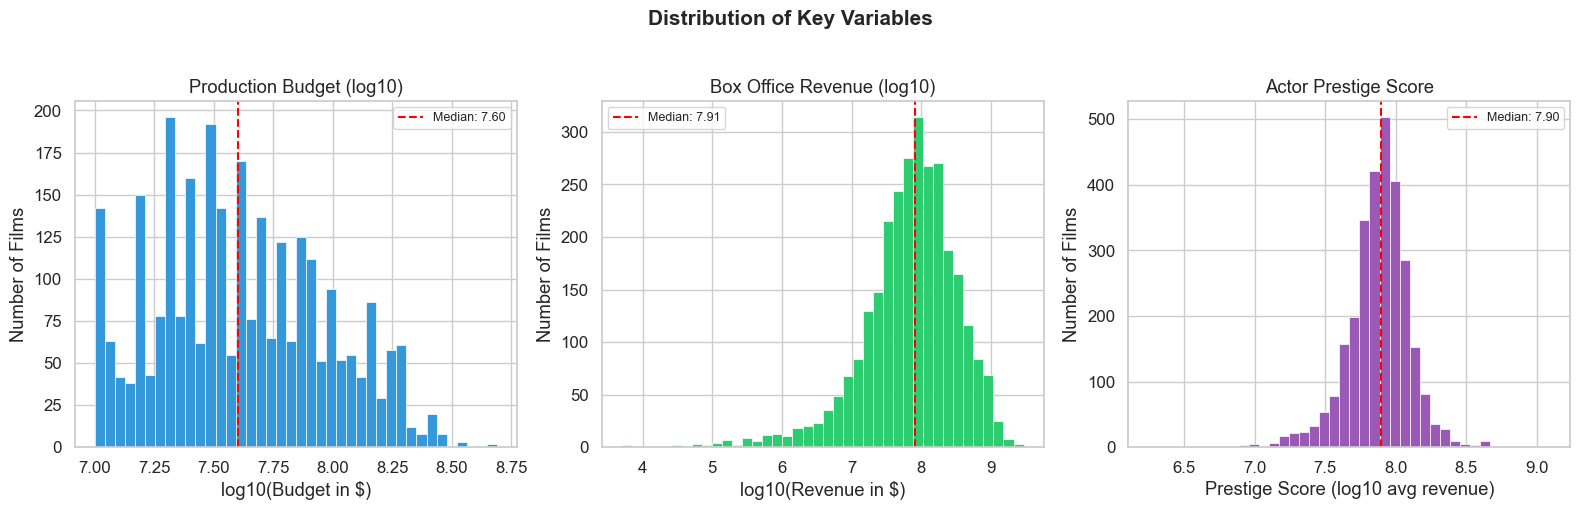

Saved: outputs/fig1_distributions.png


In [57]:
# Plot 1: Distribution of Budget, Revenue, and Actor Prestige Score
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution of Key Variables', fontsize=15, fontweight='bold', y=1.02)

# Budget distribution (log10 scale)
axes[0].hist(df['budget_log'], bins=40, color='#3498db', edgecolor='white', linewidth=0.5)
axes[0].set_title('Production Budget (log10)')
axes[0].set_xlabel('log10(Budget in $)')
axes[0].set_ylabel('Number of Films')
axes[0].axvline(df['budget_log'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {df["budget_log"].median():.2f}')
axes[0].legend(fontsize=9)

# Revenue distribution (log10 scale)
axes[1].hist(df['revenue_log'], bins=40, color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[1].set_title('Box Office Revenue (log10)')
axes[1].set_xlabel('log10(Revenue in $)')
axes[1].set_ylabel('Number of Films')
axes[1].axvline(df['revenue_log'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {df["revenue_log"].median():.2f}')
axes[1].legend(fontsize=9)

# Actor Prestige Score distribution
axes[2].hist(df['actor_prestige_score'], bins=40, color='#9b59b6', edgecolor='white', linewidth=0.5)
axes[2].set_title('Actor Prestige Score')
axes[2].set_xlabel('Prestige Score (log10 avg revenue)')
axes[2].set_ylabel('Number of Films')
axes[2].axvline(df['actor_prestige_score'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {df["actor_prestige_score"].median():.2f}')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig1_distributions.png')

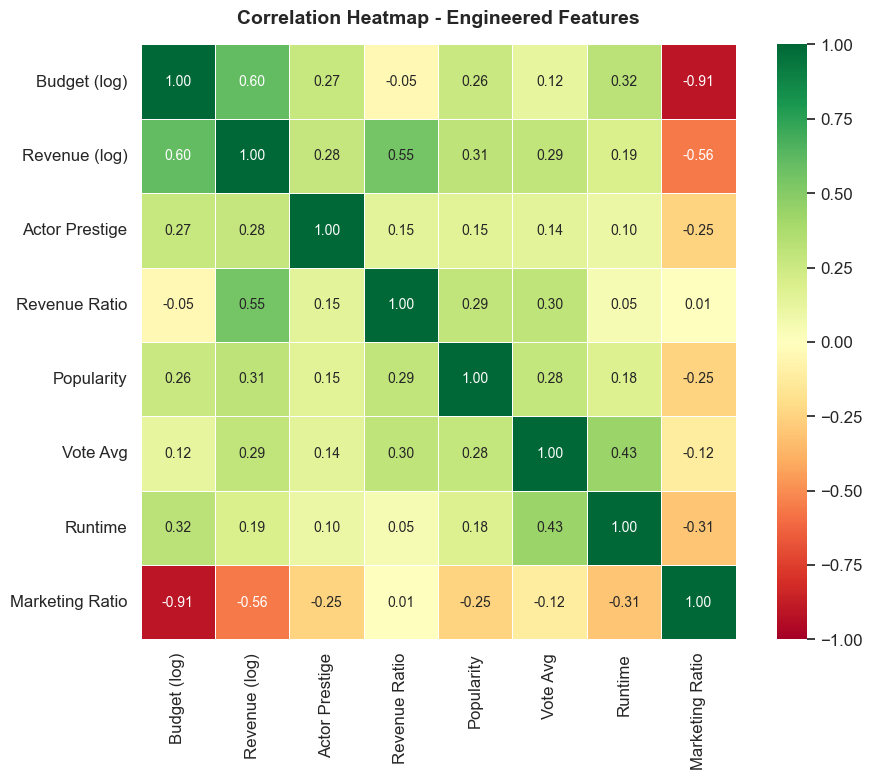

Saved: outputs/fig2_correlation_heatmap.png


In [58]:
# Plot 2: Correlation Heatmap
# Shows linear relationships between all numeric engineered features.

numeric_cols = [
    'budget_log', 'revenue_log', 'actor_prestige_score',
    'revenue_ratio', 'popularity', 'vote_average',
    'runtime', 'marketing_ratio'
]
col_labels = [
    'Budget (log)', 'Revenue (log)', 'Actor Prestige',
    'Revenue Ratio', 'Popularity', 'Vote Avg',
    'Runtime', 'Marketing Ratio'
]

corr_matrix = df[numeric_cols].corr()
corr_matrix.index   = col_labels
corr_matrix.columns = col_labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', linewidths=0.5,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, ax=ax, annot_kws={'size': 10}
)
ax.set_title('Correlation Heatmap - Engineered Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig2_correlation_heatmap.png')

In [ ]:
# Plot 3: Box Office Outcome by Budget Tier
# Shows whether higher-budget films systematically achieve better outcomes.

# Encode outcome_label as numeric for the box plot y-axis
outcome_order  = ['Flop', 'Break-even', 'Hit', 'Blockbuster']
outcome_numeric = {'Flop': 0, 'Break-even': 1, 'Hit': 2, 'Blockbuster': 3}
df['outcome_numeric'] = df['outcome_label'].map(outcome_numeric)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Box Office Outcome vs Budget', fontsize=14, fontweight='bold')

# Left: stacked bar - outcome mix per budget tier
tier_outcome = (
    df.groupby(['budget_tier', 'outcome_label'], observed=True)
    .size()
    .unstack(fill_value=0)
)
tier_outcome_pct = tier_outcome.div(tier_outcome.sum(axis=1), axis=0) * 100
tier_outcome_pct[outcome_order].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[OUTCOME_COLORS[o] for o in outcome_order],
    edgecolor='white', linewidth=0.5
)
axes[0].set_title('Outcome Mix by Budget Tier (%)')
axes[0].set_xlabel('Budget Tier')
axes[0].set_ylabel('Share of Films (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

# Right: revenue ratio distribution by budget tier
bp = axes[1].boxplot(
    [df[df['budget_tier'] == t]['revenue_ratio'].dropna().values for t in ['Low', 'Mid', 'High', 'Mega']],
    labels=['Low', 'Mid', 'High', 'Mega'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
colors = ['#85c1e9', '#82e0aa', '#f8c471', '#ec7063']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].axhline(y=2, color='red', linestyle='--', linewidth=1, label='Break-even (2x)')
axes[1].set_title('Revenue/Budget Ratio by Tier')
axes[1].set_xlabel('Budget Tier')
axes[1].set_ylabel('Revenue / Budget Ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig3_outcome_vs_budget.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig3_outcome_vs_budget.png')

In [ ]:
# Plot 4: Actor Prestige Score vs Total Gross
# The key scatter plot for our research question:
# does a higher-prestige cast actually correlate with higher box office?

fig, ax = plt.subplots(figsize=(11, 7))

for outcome in outcome_order:
    subset = df[df['outcome_label'] == outcome]
    ax.scatter(
        subset['actor_prestige_score'],
        subset['revenue_log'],
        c=OUTCOME_COLORS[outcome],
        label=outcome,
        alpha=0.55,
        s=30,
        edgecolors='none'
    )

# Add trend line
z = np.polyfit(df['actor_prestige_score'], df['revenue_log'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['actor_prestige_score'].min(), df['actor_prestige_score'].max(), 200)
ax.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', label='Trend line')

ax.set_title('Actor Prestige Score vs Box Office Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Actor Prestige Score (log10 avg career revenue)')
ax.set_ylabel('Box Office Revenue (log10 $)')
ax.legend(title='Outcome', markerscale=1.5)

# Annotate correlation
corr = df['actor_prestige_score'].corr(df['revenue_log'])
ax.text(0.03, 0.95, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig4_prestige_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: outputs/fig4_prestige_vs_revenue.png')
print(f'Pearson correlation (prestige vs revenue): {corr:.3f}')

In [ ]:
# Plot 5: Outcome Distribution by Release Window
# Does releasing in Summer or Holiday season improve box office outcomes?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Box Office Outcome by Release Window', fontsize=14, fontweight='bold')

window_order = ['Summer', 'Holiday', 'Off-season']

# Left: stacked bar - outcome mix per release window
window_outcome = (
    df.groupby(['release_window', 'outcome_label'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(window_order)
)
window_pct = window_outcome.div(window_outcome.sum(axis=1), axis=0) * 100
window_pct[outcome_order].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[OUTCOME_COLORS[o] for o in outcome_order],
    edgecolor='white', linewidth=0.5
)
axes[0].set_title('Outcome Mix by Release Window (%)')
axes[0].set_xlabel('Release Window')
axes[0].set_ylabel('Share of Films (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

# Right: median revenue ratio per window
window_stats = df.groupby('release_window')['revenue_ratio'].median().reindex(window_order)
bars = axes[1].bar(
    window_order,
    window_stats.values,
    color=['#f39c12', '#c0392b', '#7f8c8d'],
    edgecolor='white'
)
axes[1].axhline(y=2, color='red', linestyle='--', linewidth=1.5, label='Break-even (2x)')
axes[1].set_title('Median Revenue/Budget Ratio by Window')
axes[1].set_xlabel('Release Window')
axes[1].set_ylabel('Median Revenue / Budget Ratio')
for bar, val in zip(bars, window_stats.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}x', ha='center', va='bottom', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig5_outcome_by_window.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig5_outcome_by_window.png')

### Key Insights from EDA

Based on the five visualizations above, we draw the following observations
that will inform the Bayesian Network structure in Section 5:

**1. Budget and revenue are right-skewed on a raw scale**
Both variables follow an approximate log-normal distribution, confirming
that our log10 transformation in Section 2 was appropriate. A small number
of mega-hits pull the mean far above the median.

**2. Actor prestige correlates positively with revenue (but weakly)**
The scatter plot shows a positive trend, but with significant spread.
A high-prestige cast is associated with higher revenue, but it is clearly
not sufficient on its own. This supports our causal model: prestige is
one node in a larger network, not a direct cause of success.

**3. Higher budget does not guarantee a better outcome**
The stacked bar chart shows that Mega-budget films still produce a
substantial share of Flops. The revenue/budget ratio box plot shows
that Low-budget films often achieve higher multipliers when they succeed
-- consistent with the idea that budgets set a floor, not a ceiling.

**4. Summer releases dominate but Holiday releases are more efficient**
Summer has the highest volume of releases, but Holiday films tend to
achieve a higher median revenue/budget ratio. This suggests that
timing interacts with competition levels and audience appetite.

**5. Most features are weakly correlated with each other**
The heatmap confirms there is no severe multicollinearity. Features
capture different aspects of a film's commercial context, which is
exactly what we need for a well-identified Bayesian Network.